# End-to-end real-data wavelength-constraint fitting

This tutorial performs actual Gaussian-process fits on the maintained representative LPV CSV. It derives wavelength-aware parameter constraints, verifies their registration, fits a wavelength-dependent model and a meaningful control, generates predictions, calls the maintained `Lightcurve.plot()` interface, and inspects residuals and boundary pressure.


## Execution policy and scientific scope

Restart the kernel and use **Run All**. The required path sets `RUN_REQUIRED_FITS = True` and fits both `2DWavelengthDependent` and the constant-mean `2DSeparable` control. The bounded sample is deterministic and preserves every observational channel and every physical wavelength. Optional expensive extensions remain disabled.

This is a numerical and workflow demonstration, not automatic model selection or a claim that the inferred wavelength dependence is uniquely physical. Instrument-channel calibration remains `TBD[instrument-channel-calibration]`: two observational channels at one physical wavelength retain distinct identities, but this tutorial does not cross-calibrate them.


In [1]:
from pathlib import Path
import warnings

from IPython.display import HTML, display
import matplotlib.pyplot as plt
import numpy as np
import torch

from pgmuvi.wavelength_constraint_tutorial import (
    build_tutorial_fit_summary,
    build_wavelength_constraint_position_rows,
    load_wavelength_constraint_tutorial_lightcurve,
    summarize_observational_channel_residuals,
    training_point_prediction_summary,
)

SEED = 0
RUN_REQUIRED_FITS = True
RUN_OPTIONAL_EXPENSIVE_EXTENSIONS = False
MAX_SAMPLES_PER_OBSERVATIONAL_CHANNEL = 15
REQUIRED_TRAINING_ITERATIONS = 30

np.random.seed(SEED)
torch.manual_seed(SEED)
torch.set_default_dtype(torch.float64)

def display_records(records, columns=None, title=None):
    if not records:
        display(HTML("<p><em>No records.</em></p>"))
        return
    columns = list(columns or records[0])
    heading = f"<h4>{title}</h4>" if title else ""
    head = "".join(f"<th>{column}</th>" for column in columns)
    body = []
    for record in records:
        cells = []
        for column in columns:
            value = record.get(column)
            if isinstance(value, float):
                value = f"{value:.6g}"
            cells.append(f"<td>{value}</td>")
        body.append("<tr>" + "".join(cells) + "</tr>")
    table = (
        heading
        + "<table><thead><tr>"
        + head
        + "</tr></thead><tbody>"
        + "".join(body)
        + "</tbody></table>"
    )
    display(HTML(table))

def find_repository_root():
    for candidate in (Path.cwd(), *Path.cwd().parents):
        if (candidate / "examples/data/10131+3049.csv").is_file():
            return candidate
    raise FileNotFoundError("Could not locate the PGMUVI repository root.")

REPOSITORY_ROOT = find_repository_root()
SOURCE_CSV = REPOSITORY_ROOT / "examples/data/10131+3049.csv"


## 1. Load and inspect a deterministic real-data subset

Rows must have finite time, flux, uncertainty, and physical wavelength, with strictly positive flux and uncertainty. Each observational channel is sampled independently at evenly spaced time-order statistics. Channels below the quota are retained in full. This avoids selecting only the densest data stream and never collapses shared-wavelength channels.


In [2]:
primary_lightcurve, sampling_summary = load_wavelength_constraint_tutorial_lightcurve(
    SOURCE_CSV,
    max_samples_per_observational_channel=MAX_SAMPLES_PER_OBSERVATIONAL_CHANNEL,
    name="10131+3049 wavelength-dependent fit",
)
(
    control_lightcurve,
    control_sampling_summary,
) = load_wavelength_constraint_tutorial_lightcurve(
    SOURCE_CSV,
    max_samples_per_observational_channel=MAX_SAMPLES_PER_OBSERVATIONAL_CHANNEL,
    name="10131+3049 separable control",
)

assert sampling_summary == control_sampling_summary
assert sampling_summary["n_rows_retained"] > 0
assert sampling_summary["n_observational_channels_retained"] == 17
assert sampling_summary["n_physical_wavelengths_retained"] == 16
assert sampling_summary["n_physical_wavelengths_retained"] > 1
assert sampling_summary["observational_channels_by_shared_wavelength"]
assert any(
    len(channels) > 1
    for channels in sampling_summary[
        "observational_channels_by_shared_wavelength"
    ].values()
)

sampling_rows = [{
    "original rows": sampling_summary["n_rows_original"],
    "retained rows": sampling_summary["n_rows_retained"],
    "observational channels": sampling_summary["n_observational_channels_retained"],
    "physical wavelengths": sampling_summary["n_physical_wavelengths_retained"],
    "calibration status": sampling_summary["instrument_calibration_status"],
}]
display_records(sampling_rows, title="Retained real-data sample")


original rows,retained rows,observational channels,physical wavelengths,calibration status
10815,237,17,16,not_implemented


## 2. Plot the selected observations

The overview uses observational-channel labels rather than physical wavelength alone, so the two KELT data streams at their shared wavelength remain visibly distinct.


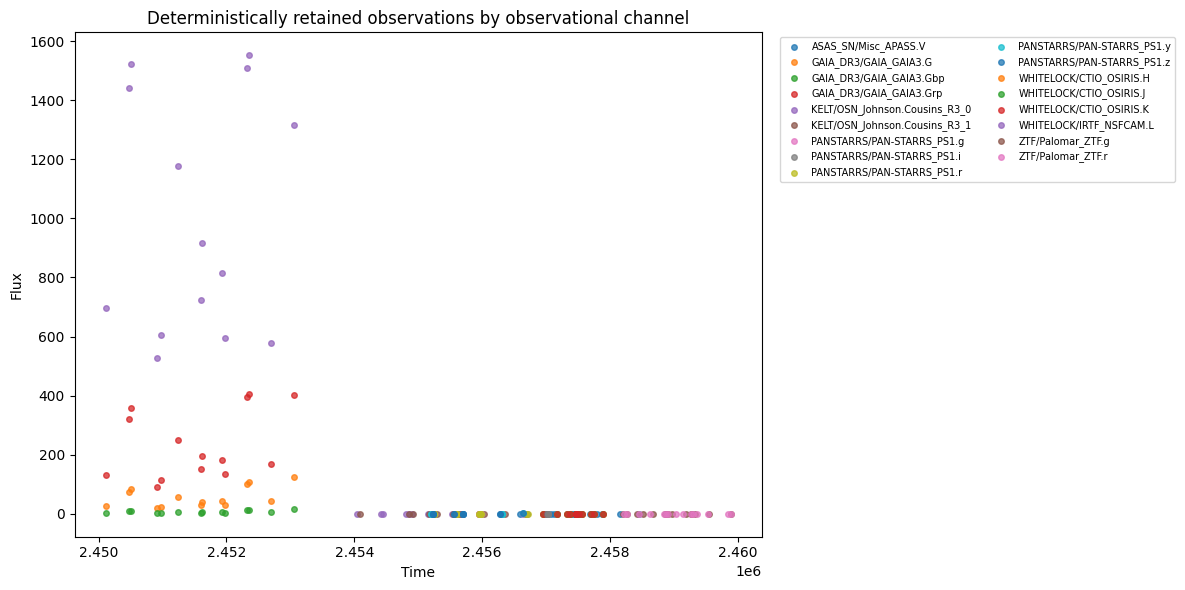

In [3]:
input_time = primary_lightcurve.xdata[:, 0].detach().cpu().numpy()
input_flux = primary_lightcurve.ydata.detach().cpu().numpy()
input_channels = np.asarray(primary_lightcurve.observational_channel_labels, dtype=str)

fig, ax = plt.subplots(figsize=(12, 6))
for observational_channel in dict.fromkeys(input_channels.tolist()):
    channel_mask = input_channels == observational_channel
    ax.scatter(
        input_time[channel_mask],
        input_flux[channel_mask],
        s=16,
        alpha=0.75,
        label=observational_channel,
    )
ax.set_xlabel("Time")
ax.set_ylabel("Flux")
ax.set_title("Deterministically retained observations by observational channel")
ax.legend(fontsize=7, ncol=2, bbox_to_anchor=(1.02, 1), loc="upper left")
fig.tight_layout()
plt.show()


## 3. Fit the wavelength-dependent model and control

Both models use the same bounded rows, quasi-periodic temporal-kernel hypothesis, optimizer, and iteration budget. `2DWavelengthDependent` adds a wavelength-dependent quadratic mean; `2DSeparable` is the constant-mean control. Both still use a smooth wavelength covariance, so this comparison asks whether the wavelength-dependent mean improves this particular bounded fit—not whether wavelength covariance itself is unnecessary.

During the parameter workflow, each final interval constraint is registered before the corresponding initial value is assigned. The post-fit table below verifies the resulting registered bounds and the initial and fitted positions.


In [4]:
FIT_KWARGS = {
    "time_kernel_type": "quasi_periodic",
    "wavelength_kernel_type": "rbf",
    "period": 600.0,
    "training_iter": REQUIRED_TRAINING_ITERATIONS,
    "miniter": REQUIRED_TRAINING_ITERATIONS,
    "stop": None,
    "optim": "Adam",
    "lr": 0.03,
    "learn_additional_noise": True,
    "use_parameter_workflow": True,
    "verbose": False,
}

assert RUN_REQUIRED_FITS, "The required Run All path must execute real fits."
with warnings.catch_warnings(record=True) as primary_warning_records:
    warnings.simplefilter("always")
    primary_fit_result = primary_lightcurve.fit(
        model="2DWavelengthDependent",
        **FIT_KWARGS,
    )

with warnings.catch_warnings(record=True) as control_warning_records:
    warnings.simplefilter("always")
    control_fit_result = control_lightcurve.fit(
        model="2DSeparable",
        **FIT_KWARGS,
    )

primary_warning_messages = [str(item.message) for item in primary_warning_records]
control_warning_messages = [str(item.message) for item in control_warning_records]
print(
    "Required GP fits completed:",
    primary_lightcurve.is_fitted,
    control_lightcurve.is_fitted,
)


Required GP fits completed: True True


## 4. Verify fit execution and objective behavior

The trainer returns the actual per-iteration negative marginal-log-likelihood history. These checks reject skipped fits, empty or non-finite histories, and a required fit whose final objective did not improve over its initial objective.


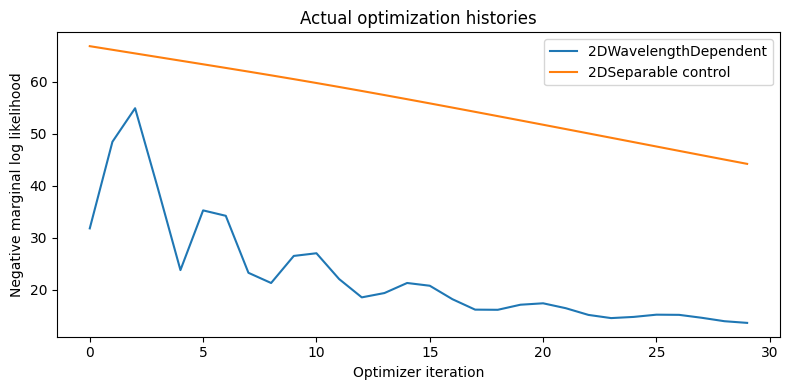

In [5]:
def validate_loss_history(lightcurve, fit_result, model_name):
    losses = np.asarray(fit_result["loss"], dtype=float)
    assert lightcurve.is_fitted, f"{model_name} did not produce a fitted model."
    assert len(lightcurve.get_fit_history()) >= 1
    assert lightcurve.get_fit_history()[-1]["success"] is True
    assert 2 <= losses.size <= REQUIRED_TRAINING_ITERATIONS
    assert np.all(np.isfinite(losses))
    assert losses[-1] < losses[0], (
        f"{model_name} final loss did not improve: "
        f"initial={losses[0]:.6g}, final={losses[-1]:.6g}"
    )
    return losses

primary_losses = validate_loss_history(
    primary_lightcurve, primary_fit_result, "2DWavelengthDependent"
)
control_losses = validate_loss_history(
    control_lightcurve, control_fit_result, "2DSeparable"
)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(primary_losses, label="2DWavelengthDependent")
ax.plot(control_losses, label="2DSeparable control")
ax.set_xlabel("Optimizer iteration")
ax.set_ylabel("Negative marginal log likelihood")
ax.set_title("Actual optimization histories")
ax.legend()
fig.tight_layout()
plt.show()


## 5. Constraint provenance and fitted boundary positions

The readable rows retain only the evidence needed to audit the workflow: exact target parameter, covariance or mean role, registered interval, initialization, fitted value, and distance to each bound. Full internal diagnostic dictionaries are not dumped.


In [6]:
primary_constraint_rows = build_wavelength_constraint_position_rows(
    primary_lightcurve, primary_fit_result
)
control_constraint_rows = build_wavelength_constraint_position_rows(
    control_lightcurve, control_fit_result
)

assert primary_constraint_rows
assert any(row["applies_to"] == "covariance" for row in primary_constraint_rows)
for row in primary_constraint_rows + control_constraint_rows:
    assert row["application_order"] == "constraint_then_value"
    assert row["constraint_registered"]
    assert np.isfinite(row["lower_bound"])
    assert np.isfinite(row["upper_bound"])
    assert row["lower_bound"] < row["upper_bound"]
    assert row["initial_inside_constraint"]
    assert np.isfinite(row["fitted_value"])
    assert row["fitted_inside_constraint"]
    assert row["distance_to_lower_bound"] >= 0.0
    assert row["distance_to_upper_bound"] >= 0.0

constraint_columns = [
    "parameter", "applies_to", "constraint_action",
    "lower_bound", "initial_value", "fitted_value", "upper_bound",
    "fractional_position_within_bounds", "minimum_distance_to_bound",
]
display_records(
    primary_constraint_rows,
    constraint_columns,
    "2DWavelengthDependent constraints",
)


parameter,applies_to,constraint_action,lower_bound,initial_value,fitted_value,upper_bound,fractional_position_within_bounds,minimum_distance_to_bound
mean_module.weights,mean,applied,-1436.67,-237.907,-180.731,1436.67,0.437101,1255.94
mean_module.weights,mean,applied,-654.765,130.953,107.33,654.765,0.58196,547.435
mean_module.bias,mean,applied,-1732.72,95.438,68.9862,2599.08,0.415925,1801.7
covar_module.kernels.1.base_kernel.lengthscale,covariance,applied,0.000409759,0.485588,0.292284,15.0758,0.0193609,0.291874


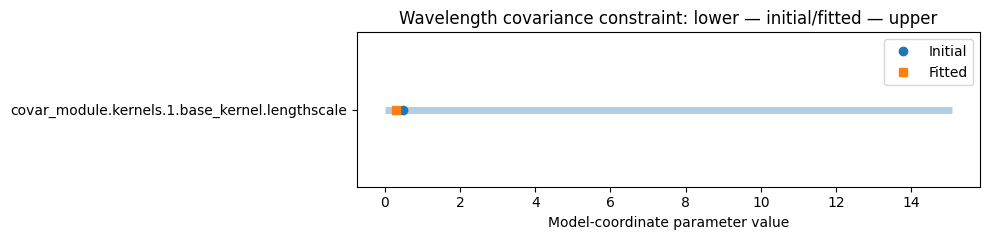

In [7]:
covariance_positions = [
    row for row in primary_constraint_rows if row["applies_to"] == "covariance"
]
fig, ax = plt.subplots(figsize=(10, max(2.5, 1.2 * len(covariance_positions))))
for row_index, row in enumerate(covariance_positions):
    ax.hlines(
        row_index,
        row["lower_bound"],
        row["upper_bound"],
        linewidth=5,
        alpha=0.35,
    )
    ax.plot(
        row["initial_value"],
        row_index,
        "o",
        label="Initial" if row_index == 0 else None,
    )
    ax.plot(
        row["fitted_value"],
        row_index,
        "s",
        label="Fitted" if row_index == 0 else None,
    )
ax.set_yticks(range(len(covariance_positions)))
ax.set_yticklabels([row["parameter"] for row in covariance_positions])
ax.set_xlabel("Model-coordinate parameter value")
ax.set_title("Wavelength covariance constraint: lower — initial/fitted — upper")
ax.legend()
fig.tight_layout()
plt.show()


### Where the constraint came from

For the covariance lengthscale, the provenance contains the physical-wavelength sampling evidence, the physical-to-model coordinate transformation, recommended initial value and derived interval, and the effective interval after intersection with any existing constraint. The table above reports the effective interval actually registered on the exact model parameter.


In [8]:
covariance_provenance = covariance_positions[0]["diagnostics"]
provenance_row = {
    "target parameter": covariance_positions[0]["parameter"],
    "applies to": covariance_positions[0]["applies_to"],
    "coordinate basis": covariance_provenance.get("coordinate_basis"),
    "raw wavelengths": covariance_provenance.get("raw_wavelengths"),
    "model wavelengths": covariance_provenance.get("model_wavelengths"),
    "recommended initial": covariance_positions[0]["estimated_value"],
    "derived interval": covariance_positions[0]["estimated_constraint"],
    "effective interval": covariance_positions[0]["effective_constraint"],
}
display_records([provenance_row], title="Constraint provenance")


target parameter,applies to,coordinate basis,raw wavelengths,model wavelengths,recommended initial,derived interval,effective interval
covar_module.kernels.1.base_kernel.lengthscale,covariance,None,None,None,0.485588,"[0.0004097593203125083, 15.0758473468239]","[0.0004097593203125083, 15.0758473468239]"


## 6. Generate finite training-point predictions

Predictions are evaluated after fitting at the retained training coordinates. Predictive means must be finite; variances must be finite and nonnegative.


In [9]:
from gpytorch.utils.warnings import GPInputWarning

with warnings.catch_warnings():
    warnings.filterwarnings("ignore", category=GPInputWarning)
    primary_predictions = training_point_prediction_summary(
        primary_lightcurve
    )
    control_predictions = training_point_prediction_summary(
        control_lightcurve
    )

for model_name, predictions in [
    ("2DWavelengthDependent", primary_predictions),
    ("2DSeparable", control_predictions),
]:
    assert np.all(np.isfinite(predictions["predictive_mean"])), model_name
    assert np.all(np.isfinite(predictions["predictive_variance"])), model_name
    assert np.all(predictions["predictive_variance"] >= 0.0), model_name
    assert np.all(np.isfinite(predictions["residual"])), model_name


## 7. Call the maintained fitted-light-curve plotting API

The call below occurs after `.fit()`. `Lightcurve.plot()` supplies observed points, predictive mean, and the 95% predictive interval. The plotting API now labels distinct observational channels separately even when they share one physical wavelength. Four representative wavelength figures are retained in this notebook to keep its size reviewable; all 16 are generated by the package call.


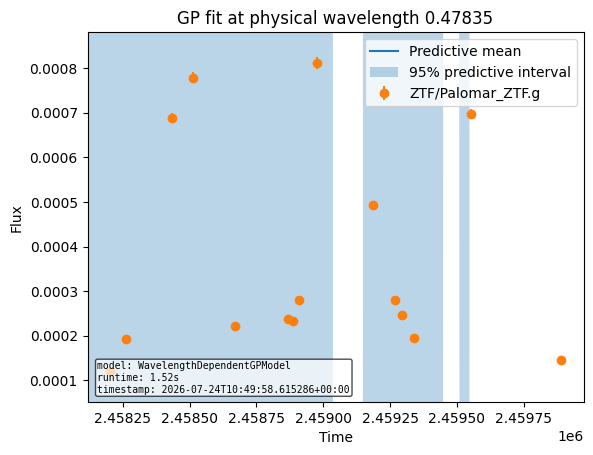

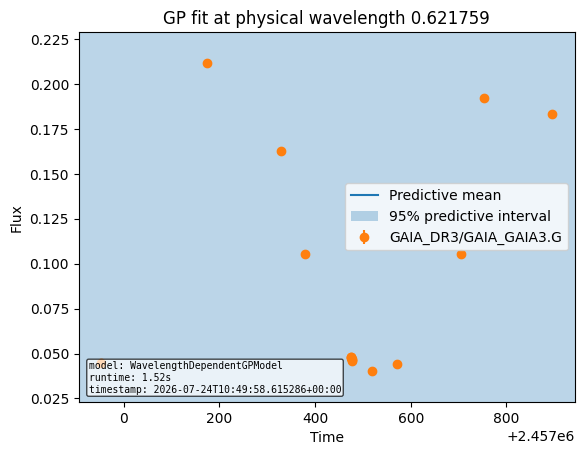

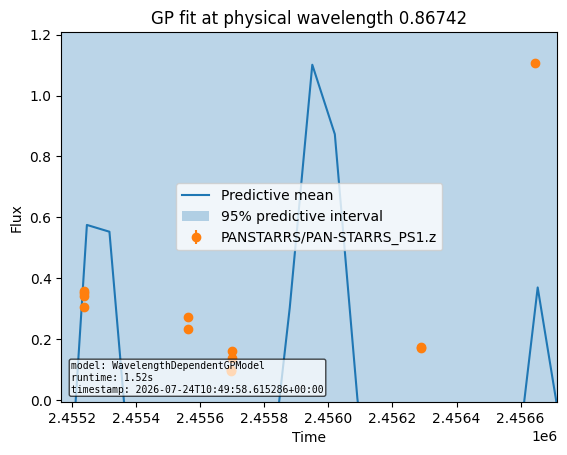

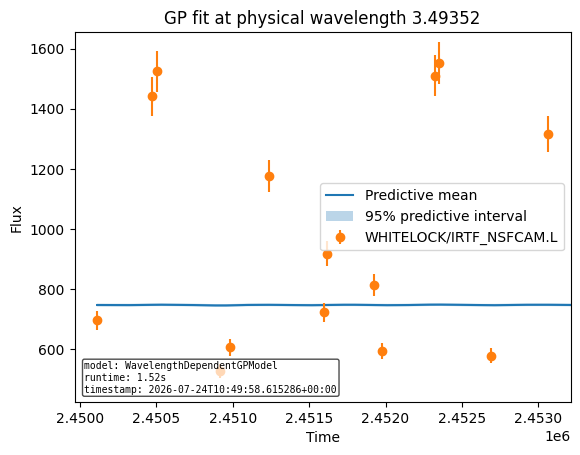

In [10]:
fitted_lightcurve_figures = primary_lightcurve.plot(
    show=False,
    save=False,
    n_pred=140,
    annotate_provenance=True,
)
assert len(fitted_lightcurve_figures) == sampling_summary[
    "n_physical_wavelengths_retained"
]
selected_figure_indices = np.unique(
    np.rint(np.linspace(0, len(fitted_lightcurve_figures) - 1, 4)).astype(int)
)
for figure_index, figure in enumerate(fitted_lightcurve_figures):
    if figure_index in selected_figure_indices:
        display(figure)
    plt.close(figure)


## 8. Residuals by time, observational channel, and physical wavelength

The first view uses standardized residuals against time and preserves observational-channel labels. The second summarizes raw residual RMSE for each observational channel against its physical wavelength. Shared-wavelength channels therefore appear as separate points rather than being silently averaged.


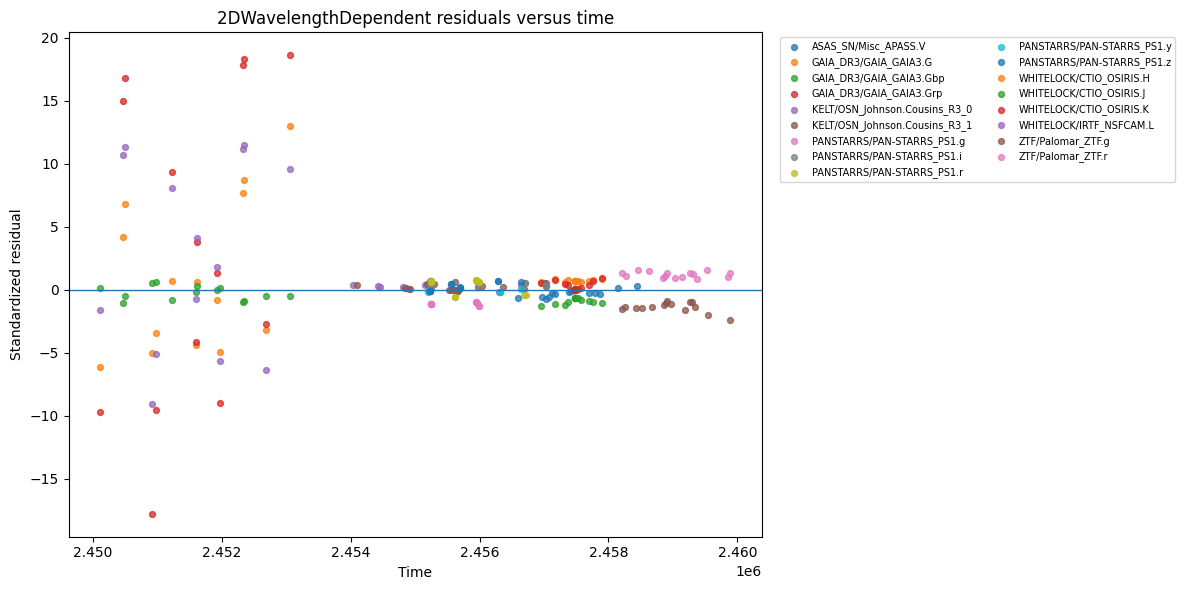

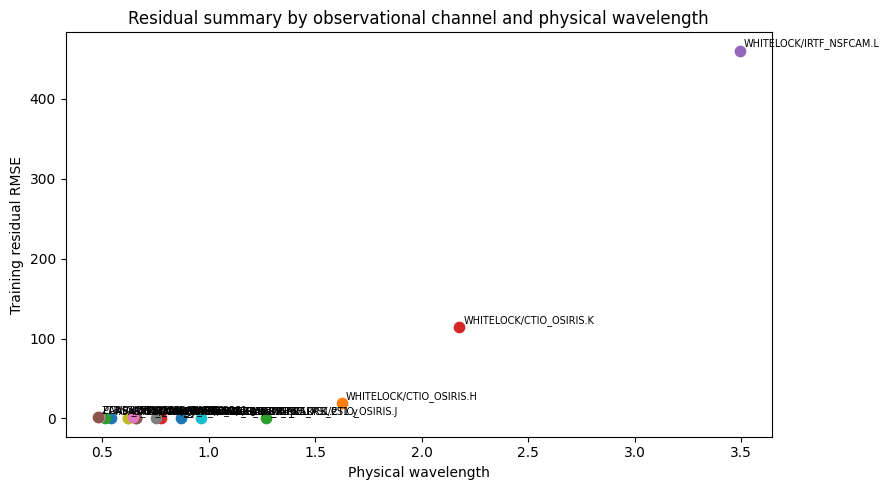

In [11]:
primary_channel_residual_rows = summarize_observational_channel_residuals(
    primary_predictions
)
assert len(primary_channel_residual_rows) == sampling_summary[
    "n_observational_channels_retained"
]

fig, ax = plt.subplots(figsize=(12, 6))
for observational_channel in dict.fromkeys(
    primary_predictions["observational_channel"].tolist()
):
    channel_mask = primary_predictions["observational_channel"] == observational_channel
    ax.scatter(
        primary_predictions["time"][channel_mask],
        primary_predictions["standardized_residual"][channel_mask],
        s=18,
        alpha=0.75,
        label=observational_channel,
    )
ax.axhline(0.0, linewidth=1)
ax.set_xlabel("Time")
ax.set_ylabel("Standardized residual")
ax.set_title("2DWavelengthDependent residuals versus time")
ax.legend(fontsize=7, ncol=2, bbox_to_anchor=(1.02, 1), loc="upper left")
fig.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(9, 5))
for row in primary_channel_residual_rows:
    wavelength = row["physical_wavelength"]
    assert isinstance(wavelength, float)
    ax.scatter(wavelength, row["rmse"], s=55)
    ax.annotate(
        row["observational_channel"],
        (wavelength, row["rmse"]),
        fontsize=7,
        xytext=(3, 3),
        textcoords="offset points",
    )
ax.set_xlabel("Physical wavelength")
ax.set_ylabel("Training residual RMSE")
ax.set_title("Residual summary by observational channel and physical wavelength")
fig.tight_layout()
plt.show()


## 9. Compare with the constant-mean control

The comparison uses identical retained rows and optimization settings. It reports rather than assumes whether the wavelength-dependent mean improves the final objective or training residual RMSE. These are descriptive training-space metrics, not population-level model-selection evidence.


In [12]:
primary_summary = build_tutorial_fit_summary(
    model_name="2DWavelengthDependent",
    lightcurve=primary_lightcurve,
    fit_result=primary_fit_result,
    sampling_summary=sampling_summary,
    constraint_rows=primary_constraint_rows,
    predictions=primary_predictions,
    warning_messages=primary_warning_messages,
)
control_summary = build_tutorial_fit_summary(
    model_name="2DSeparable",
    lightcurve=control_lightcurve,
    fit_result=control_fit_result,
    sampling_summary=sampling_summary,
    constraint_rows=control_constraint_rows,
    predictions=control_predictions,
    warning_messages=control_warning_messages,
)

comparison_rows = [
    {key: summary[key] for key in [
        "model_name", "n_iterations", "initial_loss", "final_loss",
        "residual_rmse", "objective_improved", "warning_count",
    ]}
    for summary in (primary_summary, control_summary)
]
display_records(comparison_rows, title="Wavelength-dependent model versus control")

objective_delta = control_summary["final_loss"] - primary_summary["final_loss"]
rmse_delta = control_summary["residual_rmse"] - primary_summary["residual_rmse"]
print(
    "Positive deltas favor 2DWavelengthDependent: "
    f"final-loss delta={objective_delta:.6g}; residual-RMSE delta={rmse_delta:.6g}."
)


model_name,n_iterations,initial_loss,final_loss,residual_rmse,objective_improved,warning_count
2DWavelengthDependent,30,31.8189,13.687,115.403,True,1
2DSeparable,30,66.7822,44.1994,262.037,True,1


Positive deltas favor 2DWavelengthDependent: final-loss delta=30.5124; residual-RMSE delta=146.634.


## 10. Compact fit-success summary

This final record is the concise answer to whether a real fit ran, produced finite usable predictions, moved the wavelength parameter, and pressed against a bound.


In [13]:
required_summary_fields = [
    "model_name", "n_observations", "n_observational_channels",
    "n_physical_wavelengths", "optimizer_status", "n_iterations",
    "initial_loss", "final_loss", "best_loss", "wavelength_parameter",
    "fitted_wavelength_parameter", "wavelength_lower_bound",
    "wavelength_upper_bound", "fractional_position_within_bounds",
    "minimum_distance_to_bound", "nonfinite_prediction_count",
    "negative_variance_count", "residual_rmse", "warning_count",
]
assert primary_summary["fit_executed"]
assert primary_summary["objective_improved"]
assert primary_summary["nonfinite_prediction_count"] == 0
assert primary_summary["nonfinite_variance_count"] == 0
assert primary_summary["negative_variance_count"] == 0
assert primary_summary["fitted_wavelength_parameter"] is not None
assert covariance_positions[0]["absolute_parameter_change"] > 0.0

display_records(
    [{key: primary_summary[key] for key in required_summary_fields}],
    required_summary_fields,
    "Final required-fit summary",
)


model_name,n_observations,n_observational_channels,n_physical_wavelengths,optimizer_status,n_iterations,initial_loss,final_loss,best_loss,wavelength_parameter,fitted_wavelength_parameter,wavelength_lower_bound,wavelength_upper_bound,fractional_position_within_bounds,minimum_distance_to_bound,nonfinite_prediction_count,negative_variance_count,residual_rmse,warning_count
2DWavelengthDependent,237,17,16,completed,30,31.8189,13.687,13.687,covar_module.kernels.1.base_kernel.lengthscale,0.292284,0.000409759,15.0758,0.0193609,0.291874,0,0,115.403,1


## 11. Optional expensive extensions

The required results above do not depend on this section. Researchers can increase the per-channel quota and optimization budget or add `2DDustMean`, `2DPowerLawMean`, or joint spectral-mixture `2D` comparisons after validating runtime and scientific appropriateness for their source. For joint `2D`, ARD index 0 is temporal frequency and ARD index 1 is physical-wavelength frequency.


In [14]:
if RUN_OPTIONAL_EXPENSIVE_EXTENSIONS:
    print("Increase the sample and model set deliberately before running extensions.")
else:
    print(
        "Optional expensive extensions were not run; "
        "all required fits above did run."
    )


Optional expensive extensions were not run; all required fits above did run.


## 12. Interpretation and limitations

This notebook demonstrates that the wavelength-aware mechanism executes on bounded representative real data, registers finite ordered constraints on exact model parameters before initialization, optimizes to finite fitted values, produces finite predictions, and supports visual inspection of light curves, uncertainty intervals, residuals, and boundary pressure.

It does **not** establish that the inferred wavelength dependence is unique or purely physical, that either model is universally preferred, or that one representative source proves population-level performance. Preserving two observational channels at one physical wavelength is not equivalent to scientifically cross-calibrating them. Automatic discovery and activation of a populated instrument-specific calibration catalogue remains outside this tutorial and `TBD[instrument-channel-calibration]` remains open.
